# 1. Data Loading

In [1]:
import sys
!{sys.executable} -m pip install imbalanced-learn optuna jinja2


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2

from sklearn.impute import SimpleImputer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.preprocessing import StandardScaler

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler




optuna.logging.set_verbosity(optuna.logging.WARNING)

ruta_raiz = os.path.abspath('..')
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

%load_ext autoreload
%autoreload 2
from Data_preprocesing.IQRCapper import IQRCapper


RANDOM_STATE = 42


In [4]:
X_train = pd.read_csv("../Train_test_split/X_train.csv")
X_test  = pd.read_csv("../Train_test_split/X_test.csv")
y_train = pd.read_csv("../Train_test_split/y_train.csv").squeeze()
y_test  = pd.read_csv("../Train_test_split/y_test.csv").squeeze()

target_folder = '../comparations'

def save_experiment(model_name, imbalance_method, accuracy, precision, recall, f1, roc_auc):
    new_result = {
        'Model': [model_name],
        'Imbalance_Method': [imbalance_method],
        'Accuracy': [round(accuracy, 4)],
        'Precision': [round(precision, 4)],
        'Recall': [round(recall, 4)],
        'F1_Score': [round(f1, 4)],
        'ROC_AUC': [round(roc_auc, 4)]
    }
    df_new = pd.DataFrame(new_result)
    
    # Point the file to inside the folder
    csv_file = f'{target_folder}/imbalance_results.csv'
    
    if os.path.exists(csv_file):
        df_new.to_csv(csv_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(csv_file, index=False)
        
    print(f"✅ Success! Results for {model_name} + {imbalance_method} saved in the '{target_folder}' folder.")


# 2. Class Labels

In [5]:
class_labels = {0: 'Segment 0', 1: 'Segment 1', 2: 'Segment 2', 3: 'Segment 3'}


# 3. Imbalance Mitigation

In [29]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)
        roc_auc = round(roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro'), 4)
    else:
        roc_auc = "N/A" 
        
    return {
        'Strategy': name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'F1 (macro)':round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'ROC_AUC':   roc_auc
    }

# Estimador base: DecisionTreeClassifier con profundidad 1 (stump), típico de AdaBoost
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

strategies = [
    ('No Resampling (Baseline)',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
         # Fíjate que aquí NO hay 'sampler', esa es la única diferencia
         ('clf', AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('RandomOverSampler',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
         ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('SMOTE',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('RandomUnderSampler',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('SMOTEENN',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', SMOTEENN(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

    ('SMOTETomek',
     ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', SMOTETomek(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

      ('Tomek Links',
        ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', TomekLinks()),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),

      ('Adasyn',
        ImbPipeline([
         ('capping_outliers', IQRCapper(factor=1.5)),
         ('imputacion', SimpleImputer(strategy='mean')),
         ('scaler', StandardScaler()),
         ('sampler', ADASYN(random_state=RANDOM_STATE)),
         ('clf',     AdaBoostClassifier(
             estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
             n_estimators=100, random_state=RANDOM_STATE
         ))
     ])),
]

results = []
for name, pipeline in strategies:
    print(f'Training: {name}...', end=' ')
    res = evaluate_model(pipeline, X_train, y_train, X_test, y_test, name)
    results.append(res)
    print(f'F1={res["F1 (macro)"]:.4f}')


for res in results:
    save_experiment(
            model_name="AdaBoosting",
            imbalance_method=res['Strategy'],
            accuracy=res['Accuracy'],
            precision=res['Precision'],
            recall=res['Recall'],
            f1=res['F1 (macro)'],
            roc_auc=res['ROC_AUC']
        )



results_df = pd.DataFrame(results)
print('\nDone!')

# A diferencia de GradientBoosting, AdaBoost puede beneficiarse más del rebalanceo porque
# su mecanismo de pesos de muestra (boosting weights) y los pesos de clase del estimador base
# pueden interactuar de forma complementaria. Con desbalanceo moderado, estrategias como SMOTE
# o class_weight=balanced suelen aportar mejoras más consistentes que en GBM.

Training: No Resampling (Baseline)... F1=0.6911
Training: RandomOverSampler... F1=0.6840
Training: SMOTE... F1=0.6714
Training: RandomUnderSampler... F1=0.6786
Training: SMOTEENN... F1=0.5983
Training: SMOTETomek... F1=0.6770
Training: Tomek Links... F1=0.6944
Training: Adasyn... F1=0.6614
✅ Success! Results for AdaBoosting + No Resampling (Baseline) saved in the '../comparations' folder.
✅ Success! Results for AdaBoosting + RandomOverSampler saved in the '../comparations' folder.
✅ Success! Results for AdaBoosting + SMOTE saved in the '../comparations' folder.
✅ Success! Results for AdaBoosting + RandomUnderSampler saved in the '../comparations' folder.
✅ Success! Results for AdaBoosting + SMOTEENN saved in the '../comparations' folder.
✅ Success! Results for AdaBoosting + SMOTETomek saved in the '../comparations' folder.
✅ Success! Results for AdaBoosting + Tomek Links saved in the '../comparations' folder.
✅ Success! Results for AdaBoosting + Adasyn saved in the '../comparations' fo

In [7]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'ROC_AUC']
styled = results_df.style \
    .highlight_max(subset=metric_cols, color='black') \
    .set_caption('AdaBoost Performance by Imbalance Strategy (default hyperparameters)') \
    .format({c: '{:.4f}' for c in metric_cols})
styled

,Strategy,Accuracy,Precision,Recall,F1 (macro),ROC_AUC
0,No Resampling (Baseline),0.7087,0.7137,0.6768,0.6911,0.8736
1,RandomOverSampler,0.6836,0.6708,0.7025,0.6840,0.8716
2,SMOTE,0.6737,0.6591,0.6892,0.6714,0.8651
3,RandomUnderSampler,0.6784,0.6664,0.6962,0.6786,0.8670
4,SMOTEENN,0.5971,0.5925,0.6464,0.5983,0.8631
5,SMOTETomek,0.6798,0.6650,0.6935,0.6770,0.8704
6,Tomek Links,0.7127,0.7158,0.6819,0.6944,0.8733
7,Adasyn,0.6717,0.6484,0.6824,0.6614,0.8705


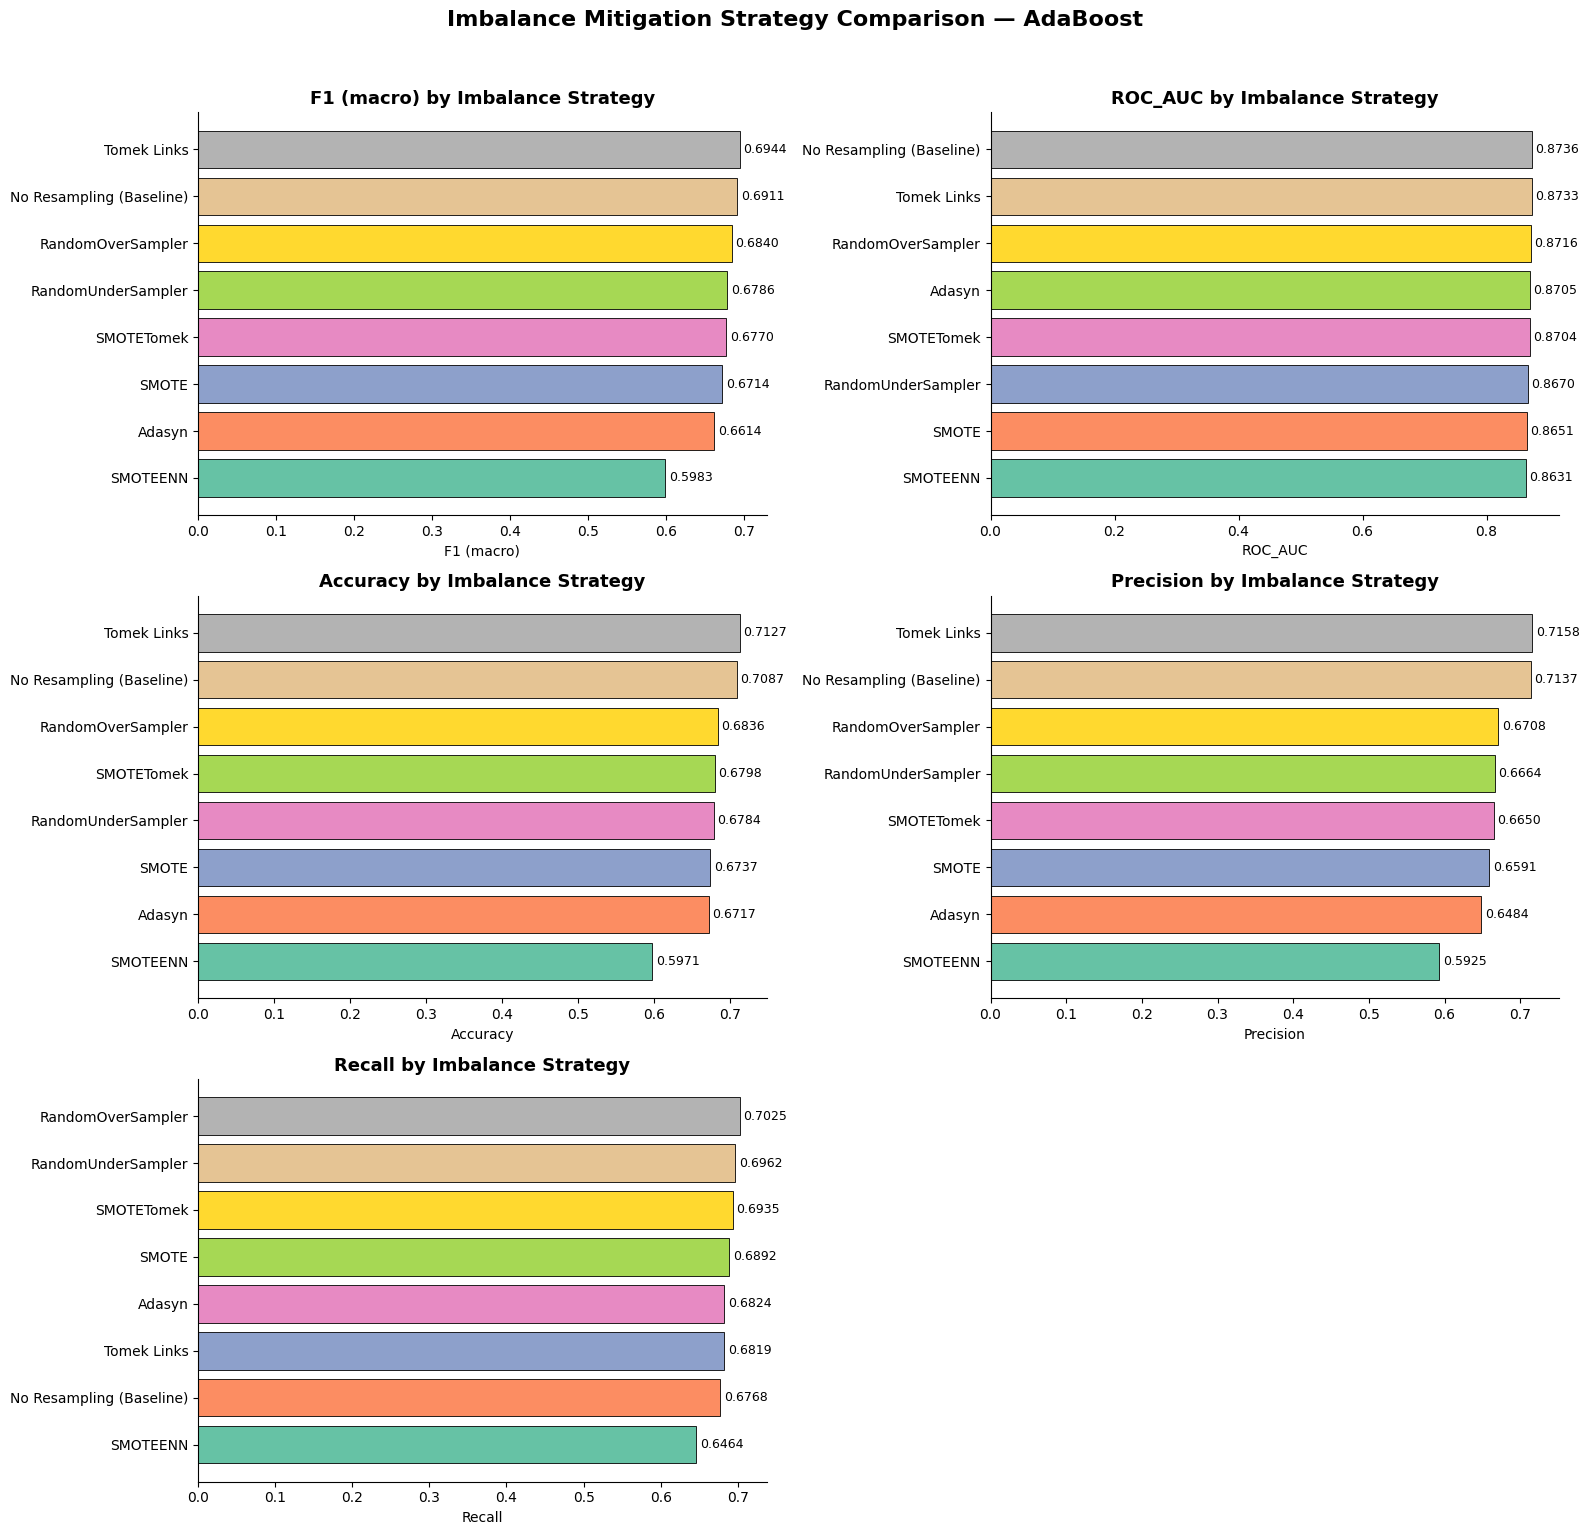

In [8]:

fig, axes = plt.subplots(3, 2, figsize=(16, 15)) 

axes_flat = axes.flatten()

metrics_to_plot = ['F1 (macro)', 'ROC_AUC', 'Accuracy', 'Precision', 'Recall']
palette = sns.color_palette('Set2', len(results_df))

for i, metric in enumerate(metrics_to_plot):
    ax = axes_flat[i]
    sorted_df = results_df.sort_values(metric, ascending=True)
    
    bars = ax.barh(sorted_df['Strategy'], sorted_df[metric], color=palette, edgecolor='black', linewidth=0.6)
    
    ax.set_title(f'{metric} by Imbalance Strategy', fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

if len(axes_flat) > len(metrics_to_plot):
    axes_flat[-1].set_axis_off()

plt.suptitle('Imbalance Mitigation Strategy Comparison — AdaBoost', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 5. Hyperparameter Tuning with Optuna



In [9]:
from sklearn.model_selection import train_test_split

best_row = results_df.loc[results_df['F1 (macro)'].idxmax()]
best_strategy_name = best_row['Strategy']
print(f'Best imbalance strategy: "{best_strategy_name}" (F1={best_row["F1 (macro)"]:.4f})')
print('\nThis strategy will be used inside the Optuna objective function.')


Best imbalance strategy: "Tomek Links" (F1=0.6944)

This strategy will be used inside the Optuna objective function.


In [12]:
def make_sampler(strategy_name, random_state=RANDOM_STATE):
    """Returns the imblearn sampler for the given strategy name."""
    mapping = {
        'RandomOverSampler': RandomOverSampler(random_state=random_state),
        'SMOTE':             SMOTE(random_state=random_state),
        'RandomUnderSampler':RandomUnderSampler(random_state=random_state),
        'SMOTEENN':          SMOTEENN(random_state=random_state),
        'SMOTETomek':        SMOTETomek(random_state=random_state),
    }
    return mapping.get(strategy_name, None)


def objective(trial):
    """Optuna objective: maximize macro F1 of AdaBoostClassifier."""
    # Espacio de hiperparámetros de AdaBoost
    n_estimators     = trial.suggest_int('n_estimators', 50, 500)
    learning_rate    = trial.suggest_float('learning_rate', 0.01, 2.0, log=True)
    max_depth        = trial.suggest_int('max_depth', 1, 5)          # profundidad del árbol base
    min_samples_split= trial.suggest_int('min_samples_split', 2, 20)  # del árbol base

    base_est = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=RANDOM_STATE
    )

    # Si la mejor estrategia usa class_weight, inyectarlo en el árbol base
    if best_strategy_name == 'class_weight=balanced':
        base_est = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )

    clf = AdaBoostClassifier(
        estimator=base_est,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=RANDOM_STATE
    )

    # Wrap en pipeline de resampling si aplica
    sampler = make_sampler(best_strategy_name)
    if sampler is not None:
        model = ImbPipeline([
        ('capping_outliers', IQRCapper(factor=1.5)),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('sampler', sampler), ('clf', clf)])
    else:
        model = ImbPipeline([
        ('capping_outliers', IQRCapper(factor=1.5)),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

    # Train/Val split 80/20 estratificado
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

    trial.report(f1, 0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return f1


print('Objective function defined using AdaBoostClassifier.')


Objective function defined using AdaBoostClassifier.


In [13]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1)
)

print('Starting Optuna optimization (30 trials)...')
print('Pruner: MedianPruner — unpromising trials will be cut early.\n')


study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nOptimization complete!')
print(f'Best trial:  #{study.best_trial.number}')
print(f'Best CV F1:  {study.best_value:.4f}')
print(f'Best params: {study.best_params}')


Starting Optuna optimization (30 trials)...
Pruner: MedianPruner — unpromising trials will be cut early.



Best trial: 12. Best value: 0.757886: 100%|██████████| 30/30 [24:42<00:00, 49.41s/it]


Optimization complete!
Best trial:  #12
Best CV F1:  0.7579
Best params: {'n_estimators': 487, 'learning_rate': 0.06980395524831928, 'max_depth': 5, 'min_samples_split': 2}


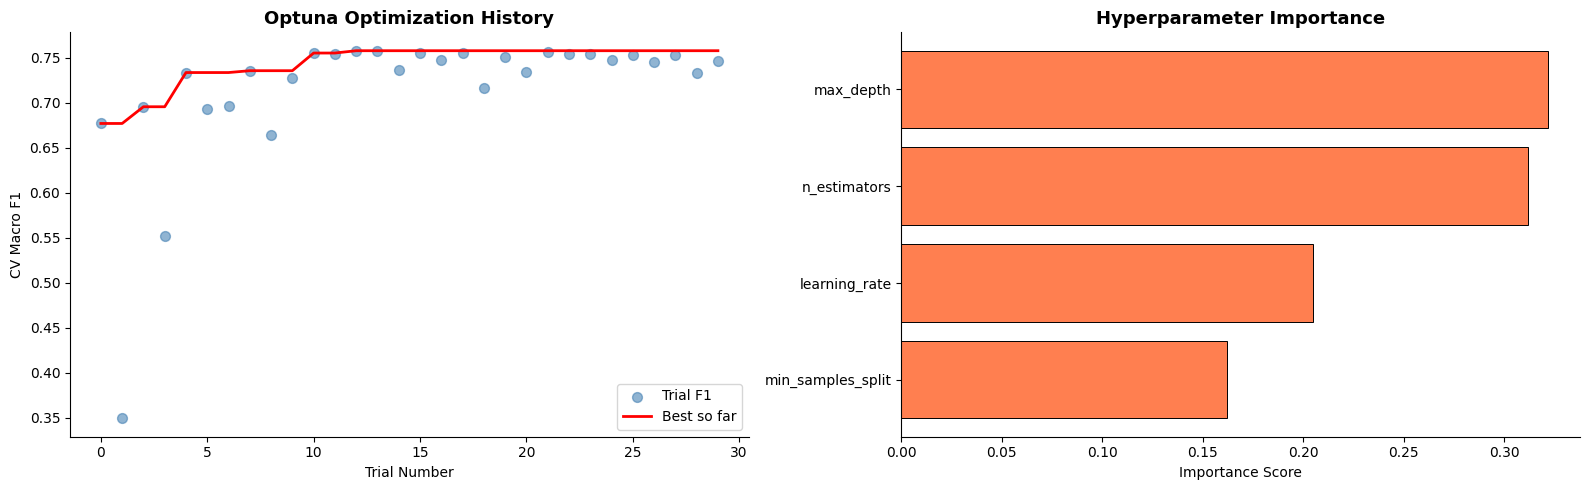


Completed trials: 30 | Pruned trials: 0
Pruning rate: 0.0% — MedianPruner saved computation time.


In [14]:
# --- Plot optimization history ---
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

axes[0].scatter(trial_nums, trial_vals, alpha=0.6, color='steelblue', s=50, label='Trial F1')
axes[0].plot(trial_nums, best_so_far, color='red', linewidth=2, label='Best so far')
pruned_nums = [t.number for t in pruned]
if pruned_nums:
    axes[0].axvline(x=pruned_nums[0], color='grey', linestyle='--', alpha=0.4, label='Pruned trials')
    for pn in pruned_nums[1:]:
        axes[0].axvline(x=pn, color='grey', linestyle='--', alpha=0.4)
axes[0].set_title('Optuna Optimization History', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('CV Macro F1')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Parameter importance (top 6)
importances = optuna.importance.get_param_importances(study)
imp_df = pd.DataFrame(list(importances.items()), columns=['Parameter', 'Importance']).head(6)
imp_df = imp_df.sort_values('Importance')
axes[1].barh(imp_df['Parameter'], imp_df['Importance'], color='coral', edgecolor='black', linewidth=0.7)
axes[1].set_title('Hyperparameter Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nCompleted trials: {len(completed)} | Pruned trials: {len(pruned)}')
print(f'Pruning rate: {len(pruned)/len(study.trials)*100:.1f}% — MedianPruner saved computation time.')


# 6. AdaBoost with Best Parameters

In [16]:
best_params = study.best_params.copy()

base_estimator_params = {
    'max_depth': best_params.pop('max_depth'),
    'min_samples_split': best_params.pop('min_samples_split'),
    'random_state': RANDOM_STATE
}
if best_strategy_name == 'class_weight=balanced':
    base_estimator_params['class_weight'] = 'balanced'

best_base_est = DecisionTreeClassifier(**base_estimator_params)

final_clf = AdaBoostClassifier(
    estimator=best_base_est,
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    random_state=RANDOM_STATE
)

sampler = make_sampler(best_strategy_name)
if sampler is not None:
    final_model = ImbPipeline([
            ('capping_outliers', IQRCapper(factor=1.5)),
            ('imputacion', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('sampler', sampler), 
            ('clf', final_clf)])
    final_model.fit(X_train, y_train)
else:
    final_model = ImbPipeline([
        ('capping_outliers', IQRCapper(factor=1.5)),
        ('imputacion', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('clf', final_clf)
    ])
    final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print('Final model trained on full training set (AdaBoost).')
print(f'Strategy: {best_strategy_name}')
print(f'Best params: {study.best_params}')


Final model trained on full training set (AdaBoost).
Strategy: Tomek Links
Best params: {'n_estimators': 487, 'learning_rate': 0.06980395524831928, 'max_depth': 5, 'min_samples_split': 2}


In [28]:
from IPython.display import display
# 1. Cálculo de métricas globales
y_score = final_model.predict_proba(X_test) 

acc  = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, average='macro', zero_division=0)
rec  = recall_score(y_test, y_pred_final, average='macro', zero_division=0)
f1   = f1_score(y_test, y_pred_final, average='macro', zero_division=0)
roc_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')

metrics_final = pd.DataFrame([{
    'Accuracy': acc,
    'Precision (macro)': prec,
    'Recall (macro)': rec,
    'F1 (macro)': f1,
    'ROC_AUC': roc_auc
}])

report_dict = classification_report(
    y_test, y_pred_final, 
    target_names=[class_labels[i] for i in range(4)], 
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()


styled_metrics = (metrics_final.style
    .format("{:.4f}")
    .set_caption("🎯 FINAL MODEL — TEST SET RESULTS")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#333'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '15px'), ('padding', '8px')]}
    ])
    .hide(axis="index")
)

report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

styled_report = (report_df.style
    .format("{:.4f}", subset=['precision', 'recall', 'f1-score'])
    .format("{:.0f}", subset=['support'])
    .set_caption("PER-CLASS REPORT")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#333'), ('margin-bottom', '10px'), ('margin-top', '20px')]},
        {'selector': 'th', 'props': [('background-color', '#2C3E50'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]}
    ]) 
)


# Mostrar las tablas usando el motor de IPython en lugar de print
display(styled_metrics)
display(styled_report)

Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC_AUC
0.7529,0.7679,0.7450,0.7553,0.9098


,precision,recall,f1-score,support
Segment 0,0.8350,0.7725,0.8026,1055
Segment 1,0.8301,0.7838,0.8063,1832
Segment 2,0.7665,0.8360,0.7998,4422
Segment 3,0.6398,0.5875,0.6126,2691


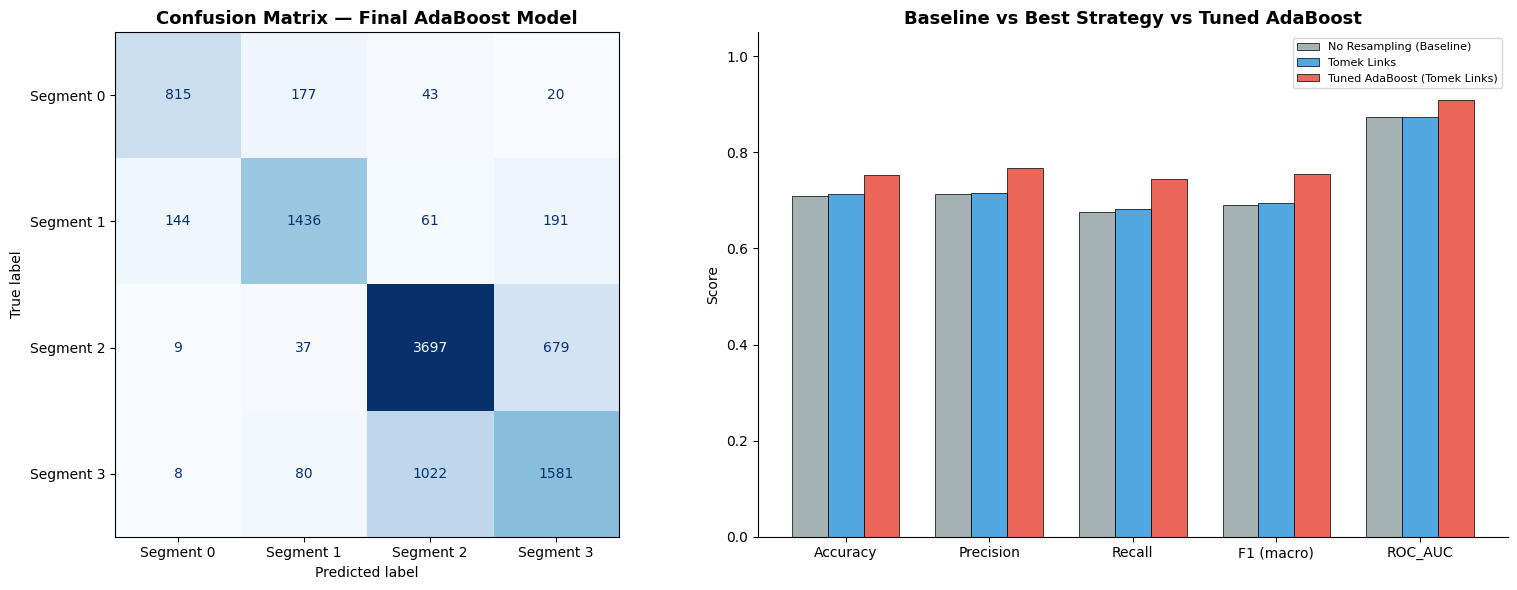

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=[class_labels[i] for i in range(4)],
    colorbar=False,
    ax=axes[0],
    cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Final AdaBoost Model', fontsize=13, fontweight='bold')

# Compare baseline vs tuned
compare_df = results_df[results_df['Strategy'].isin(['No Resampling (Baseline)', best_strategy_name])].copy()
tuned_row = pd.DataFrame([{
    'Strategy': f'Tuned AdaBoost ({best_strategy_name})',
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1 (macro)': round(f1, 4),
    'ROC_AUC': round(roc_auc, 4)
}])
compare_df = pd.concat([compare_df, tuned_row], ignore_index=True)

metrics_to_bar = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'ROC_AUC']
x = np.arange(len(metrics_to_bar))
width = 0.25
bar_colors = ['#95a5a6', '#3498db', '#e74c3c']

for i, (_, row) in enumerate(compare_df.iterrows()):
    vals = [row[m] for m in metrics_to_bar]
    bars = axes[1].bar(x + i*width, vals, width, label=row['Strategy'], color=bar_colors[i], alpha=0.85, edgecolor='black', linewidth=0.6)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics_to_bar)
axes[1].set_title('Baseline vs Best Strategy vs Tuned AdaBoost', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#La confusion matrix muestra que tan bien esta clasificado todo, errores etc
#Y luego tenemos la muestra de las metricas de performance basandonos en los 3 mejores modelos y el tuned
#Podemos ver que sucede lo mismo que en GradientBoosting, esto sugiere que el segmento 2 y 3 comparten
#Features parecidas, junto con el buen desempeño estadistico del segmento 2 hace que este se coma el 
#Segmento 3
